In [1]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn import tree
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(r"C:\Users\utkar\1csv\DL1.csv")
df

,Outlook,Temp,Humidity,Wind,Game
0,Sunny,Hot,High,Weak,0
1,Sunny,Hot,High,Strong,0
2,Overcast,Hot,High,Weak,1
3,Rain,Mild,High,Weak,1
4,Rain,Cool,Normal,Weak,1
5,Rain,Cool,Normal,Strong,0
6,Overcast,Cool,Normal,Strong,1
7,Sunny,Mild,High,Weak,0
8,Sunny,Cool,Normal,Weak,1
9,Rain,Mild,Normal,Weak,1


In [3]:
input = df.drop(['Game'], axis='columns')
Target = df.Game


In [4]:
le_outlook = LabelEncoder()
le_temp = LabelEncoder()
le_humidity = LabelEncoder()
le_wind = LabelEncoder()

In [5]:
input['outlook_n'] = le_outlook.fit_transform(input['Outlook'])
input['temp_n'] = le_temp.fit_transform(input['Temp'])
input['humidity_n'] = le_humidity.fit_transform(input['Humidity'])
input['wind_n'] = le_wind.fit_transform(input['Wind'])

In [11]:
input_n = input.drop(['Outlook', 'Temp', 'Humidity','Wind'], axis='columns')
input_n

,outlook_n,temp_n,humidity_n,wind_n
0,2,1,0,1
1,2,1,0,0
2,0,1,0,1
3,1,2,0,1
4,1,0,1,1
5,1,0,1,0
6,0,0,1,0
7,2,2,0,1
8,2,0,1,1
9,1,2,1,1


In [8]:
model = tree.DecisionTreeClassifier()
model.fit(input_n, Target)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [9]:
accuracy = model.score(input_n, Target)
print("Model Accuracy:", accuracy)

Model Accuracy: 1.0


In [10]:
prediction = model.predict([[2,2,2,2]])
print("Prediction:", prediction)

Prediction: [1]


D:\sem4\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


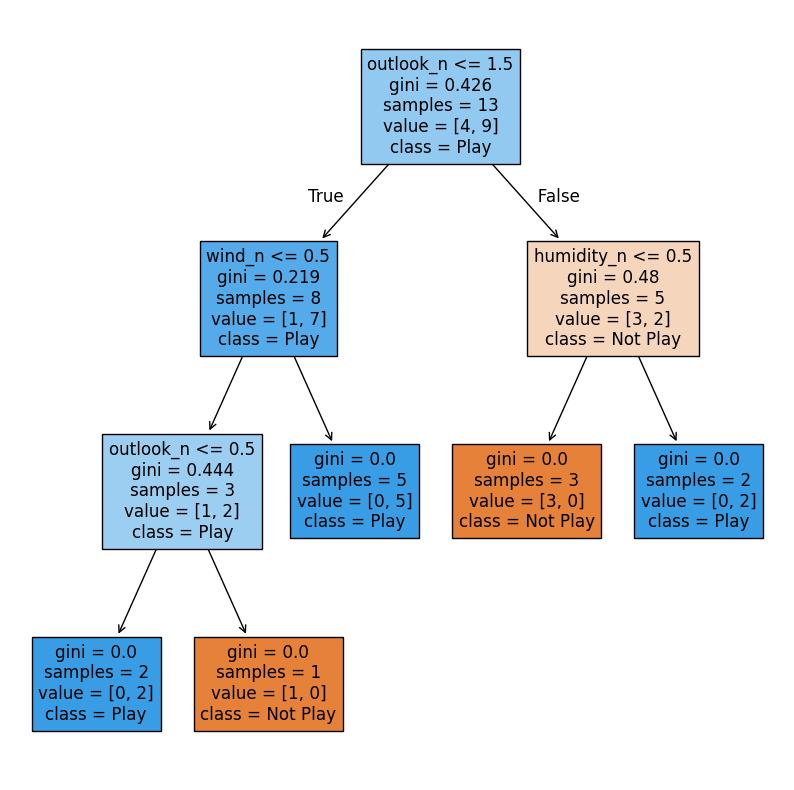

In [16]:
plt.figure(figsize= (10,10))
tree.plot_tree(model, feature_names=input_n.columns, class_names= ["Not Play", "Play"], filled=True)
plt.show()